# Customer Churn Prediction

# LightGBM Model

## Objective

Train and optimize a LightGBM classifier for customer churn prediction.
The model performance will be compared with XGBoost and CatBoost.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from lightgbm import LGBMClassifier

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Libraries Loaded Successfully!")

Libraries Loaded Successfully!


In [2]:
df = pd.read_csv("../data/cleaned_telco.csv")

print(df.shape)

df.head()

(7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
X = df.drop("Churn", axis=1)

y = df["Churn"].map({
    "No":0,
    "Yes":1
})

In [4]:
numerical_cols = X.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical:", numerical_cols)

print("Categorical:", categorical_cols)

Numerical: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    stratify=y,

    random_state=42

)

In [6]:
encoder = OneHotEncoder(

    sparse_output=False,

    handle_unknown="ignore"

)

X_train_cat = encoder.fit_transform(
    X_train[categorical_cols]
)

X_test_cat = encoder.transform(
    X_test[categorical_cols]
)

In [7]:
scaler = StandardScaler()

X_train_num = scaler.fit_transform(
    X_train[numerical_cols]
)

X_test_num = scaler.transform(
    X_test[numerical_cols]
)

In [8]:
X_train = np.hstack([

    X_train_num,

    X_train_cat

])

X_test = np.hstack([

    X_test_num,

    X_test_cat

])

print(X_train.shape)

print(X_test.shape)

(5634, 45)
(1409, 45)


In [9]:
lgbm = LGBMClassifier(
    random_state=42,
    verbose=-1,
)

In [10]:
param_grid = {

    "n_estimators": [200, 400, 600, 800, 1000],

    "learning_rate": [0.005, 0.01, 0.03, 0.05],

    "max_depth": [4, 5, 6, 8, 10, -1],

    "num_leaves": [31, 50, 70, 100, 127],

    "min_child_samples": [5, 10, 20, 30],

    "subsample": [0.8, 0.9, 1.0],

    "colsample_bytree": [0.8, 0.9, 1.0],

    "reg_alpha": [0, 0.1, 0.5, 1],

    "reg_lambda": [0, 0.1, 0.5, 1]
}

In [11]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(

    estimator=lgbm,

    param_distributions=param_grid,

    n_iter=50,

    scoring="roc_auc",

    cv=5,

    random_state=42,

    verbose=2,

    n_jobs=-1

)

In [12]:
random_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","LGBMClassifie...2, verbose=-1)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 0.9, ...], 'learning_rate': [0.005, 0.01, ...], 'max_depth': [4, 5, ...], 'min_child_samples': [5, 10, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a functi

In [13]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest ROC-AUC:")
print(random_search.best_score_)

Best Parameters:
{'subsample': 1.0, 'reg_lambda': 0.1, 'reg_alpha': 0.1, 'num_leaves': 70, 'n_estimators': 200, 'min_child_samples': 30, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 1.0}

Best ROC-AUC:
0.8485734019535334


In [14]:
best_lgbm = random_search.best_estimator_

In [15]:

# Probability of churn
y_prob = best_lgbm.predict_proba(X_test)[:, 1]

# Custom threshold
THRESHOLD = 0.40

y_pred = (y_prob >= THRESHOLD).astype(int)

In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")

Accuracy : 0.7878
Precision: 0.5959
Recall   : 0.6230
F1 Score : 0.6092
ROC-AUC  : 0.8448


In [17]:
%history


import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from lightgbm import LGBMClassifier

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Libraries Loaded Successfully!")
df = pd.read_csv("../data/cleaned_telco.csv")

print(df.shape)

df.head()
X = df.drop("Churn", axis=1)

y = df["Churn"].map({
    "No":0,
    "Yes":1
})
numerical_cols = X.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical:", numerical_cols)

print("Categorical:", categorical_cols)
X_train, X_test, y_train, y_tes

In [18]:
# =====================================================
# Predict Entire Dataset
# =====================================================

X_cat = encoder.transform(X[categorical_cols])

X_num = scaler.transform(X[numerical_cols])

X_full = np.hstack([
    X_num,
    X_cat
])

pred = best_lgbm.predict(X_full)

print("Predicted Churn Customers :", pred.sum())
print("Predicted Churn Rate :", pred.mean() * 100)

print("Actual Churn Customers :", y.sum())
print("Actual Churn Rate :", y.mean() * 100)

Predicted Churn Customers : 1203
Predicted Churn Rate : 17.080789436319748
Actual Churn Customers : 1869
Actual Churn Rate : 26.536987079369588


In [19]:
prob = best_lgbm.predict_proba(X_full)[:, 1]

print("Min Probability :", prob.min())
print("Max Probability :", prob.max())
print("Average Probability :", prob.mean())

Min Probability : 0.044031001564443666
Max Probability : 0.7866255010284479
Average Probability : 0.26551933854205306


In [20]:
for t in [0.30, 0.40, 0.50, 0.60, 0.70]:
    pred = (prob >= t).astype(int)

    print(
        f"Threshold {t:.2f}  ->  "
        f"{pred.sum()} customers  "
        f"({pred.mean()*100:.2f}%)"
    )

Threshold 0.30  ->  2695 customers  (38.26%)
Threshold 0.40  ->  1886 customers  (26.78%)
Threshold 0.50  ->  1203 customers  (17.08%)
Threshold 0.60  ->  616 customers  (8.75%)
Threshold 0.70  ->  207 customers  (2.94%)


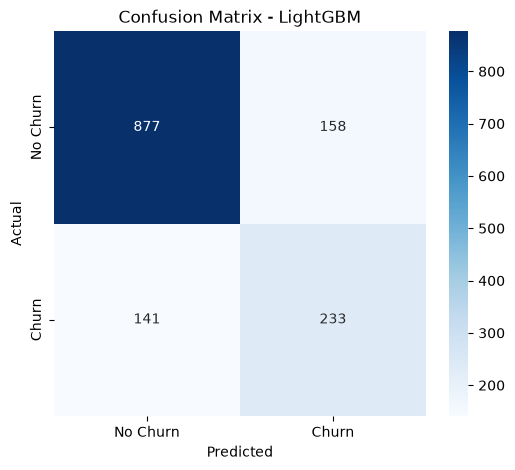

In [21]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn","Churn"],
    yticklabels=["No Churn","Churn"]
)

plt.title("Confusion Matrix - LightGBM")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [22]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.85      0.85      1035
           1       0.60      0.62      0.61       374

    accuracy                           0.79      1409
   macro avg       0.73      0.74      0.73      1409
weighted avg       0.79      0.79      0.79      1409



In [23]:
feature_names = numerical_cols + list(
    encoder.get_feature_names_out(categorical_cols)
)

importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance": best_lgbm.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
2,MonthlyCharges,548
1,tenure,448
3,TotalCharges,382
43,PaymentMethod_Electronic check,255
37,Contract_One year,209
18,OnlineSecurity_No,192
36,Contract_Month-to-month,169
39,PaperlessBilling_No,108
27,TechSupport_No,96
35,StreamingMovies_Yes,91


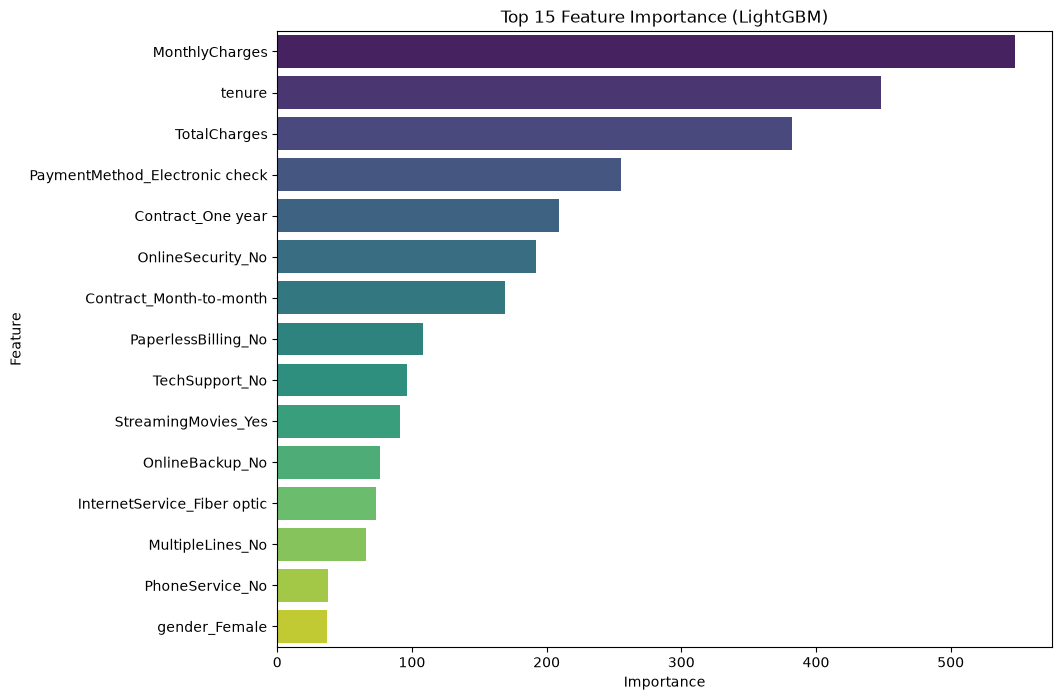

In [24]:
plt.figure(figsize=(10,8))

sns.barplot(

    data=importance.head(15),

    x="Importance",

    y="Feature",

    palette="viridis"

)

plt.title("Top 15 Feature Importance (LightGBM)")

plt.show()

In [25]:
%history

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from lightgbm import LGBMClassifier

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Libraries Loaded Successfully!")
df = pd.read_csv("../data/cleaned_telco.csv")

print(df.shape)

df.head()
X = df.drop("Churn", axis=1)

y = df["Churn"].map({
    "No":0,
    "Yes":1
})
numerical_cols = X.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical:", numerical_cols)

print("Categorical:", categorical_cols)
X_train, X_test, y_train, y_tes

In [26]:
joblib.dump(
    best_lgbm,
    "../models/lightgbm_model.pkl"
)

['../models/lightgbm_model.pkl']

In [27]:
joblib.dump(
    encoder,
    "../models/encoder.pkl"
)

['../models/encoder.pkl']

In [28]:
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']

In [29]:
joblib.dump(
    feature_names,
    "../models/feature_names.pkl"
)

['../models/feature_names.pkl']

In [30]:
# Save deployment threshold
joblib.dump(
    THRESHOLD,
    "../models/threshold.pkl"
)

['../models/threshold.pkl']